In [1]:
import os

In [2]:
os.getcwd()

'C:\\Users\\eddie\\MDS 620'

In [3]:
import pandas as pd
from sklearn import preprocessing
from sklearn.metrics import pairwise
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
import matplotlib.pylab as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates

In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from mord import LogisticIT
from dmba import classificationSummary, gainsChart, liftChart
from dmba.metric import AIC_score


In [5]:
pip install --upgrade mord

Note: you may need to restart the kernel to use updated packages.


In [6]:
ibm_df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [7]:
ibm_df.drop(['StandardHours','EmployeeCount', 'EmployeeNumber'], axis=1, inplace=True)

In [8]:
ibm_df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [9]:
ibm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [10]:
ibm_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0


In [11]:
# treat Performance ratings as categorical and convert it to a dummy variable

ibm_df['PerformanceRating'] = ibm_df['PerformanceRating'].astype('category')
new_categories = {1: 'Low', 2: 'Good', 3: 'Excellent', 4: 'Outstanding'}
ibm_df.PerformanceRating.cat.rename_categories(new_categories)
ibm_df = pd.get_dummies(ibm_df, prefix_sep='_', drop_first=True)

In [12]:
print(ibm_df.columns.tolist())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Yes', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Married', 'MaritalStatus_Sing

In [13]:
# Partition the data

y = ibm_df['Attrition_Yes']
X = ibm_df.drop(columns=['Attrition_Yes'])
train_X, valid_X, train_y, valid_y = train_test_split(X,y, test_size=0.4, random_state=1)

In [14]:
train_y_encoded = train_y.astype('category').cat.codes
valid_y_encoded = valid_y.astype('category').cat.codes


In [15]:
ibm_df.columns.tolist()

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'Attrition_Yes',
 'BusinessTravel_Travel_Frequently',
 'BusinessTravel_Travel_Rarely',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'Gender_Male',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Manager',
 'JobRole_Manufacturing Director',
 'JobRole_Research Director',
 'JobRole_Research Scientist',
 'JobRole_Sales Executive',
 'JobRole_Sales Representative',
 'Ma

In [16]:
# Fit a logistic regression

logit_reg = LogisticRegression(penalty='l2', C=1e42, solver='liblinear')
logit_reg.fit(train_X, train_y_encoded)

valid_y_pred_encoded = logit_reg.predict(valid_X)

In [17]:
print('intercept ', logit_reg.intercept_[0])
print(pd.DataFrame({'coeff': logit_reg.coef_[0]}, index=X.columns).transpose())

print('AIC', AIC_score(valid_y, logit_reg.predict(valid_X), df = len(train_X.columns) + 1))

intercept  0.13343647065830233
            Age  DailyRate  DistanceFromHome  Education  \
coeff -0.005563  -0.000262          0.036232   0.142471   

       EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
coeff                -0.357212    0.006991       -0.292609  0.020569   

       JobSatisfaction  MonthlyIncome  ...  JobRole_Manager  \
coeff        -0.184624      -0.000077  ...         0.008161   

       JobRole_Manufacturing Director  JobRole_Research Director  \
coeff                       -0.152789                  -0.031415   

       JobRole_Research Scientist  JobRole_Sales Executive  \
coeff                    -0.18137                -0.026962   

       JobRole_Sales Representative  MaritalStatus_Married  \
coeff                      0.299691               -0.10299   

       MaritalStatus_Single  OverTime_Yes  PerformanceRating_4  
coeff               0.46497      1.181663            -0.146145  

[1 rows x 44 columns]
AIC 630.3124798813649


In [18]:
logit_reg_pred = logit_reg.predict(valid_X)
logit_reg_proba = logit_reg.predict_proba(valid_X)
logit_result = pd.DataFrame({'actual': valid_y,
                             'p(0)': [p[0] for p in logit_reg_proba],
                             'p(1)': [p[1] for p in logit_reg_proba],
                             ' predicted': logit_reg_pred })

In [19]:
interestingCases = [419, 355, 819, 1140]
# Keep only the indices that exist in the DataFrame's index
existing_cases = [case for case in interestingCases if case in logit_result.index]

# Print the rows for the valid indices
print(logit_result.loc[existing_cases])


      actual      p(0)      p(1)   predicted
419    False  0.949051  0.050949           0
355    False  0.945468  0.054532           0
819    False  0.853717  0.146283           0
1140   False  0.983516  0.016484           0


In [20]:
classificationSummary(train_y, logit_reg.predict(train_X))

classificationSummary(valid_y, logit_reg.predict(valid_X))

Confusion Matrix (Accuracy 0.8878)

       Prediction
Actual   0   1
     0 745   2
     1  97  38
Confusion Matrix (Accuracy 0.8537)

       Prediction
Actual   0   1
     0 475  11
     1  75  27


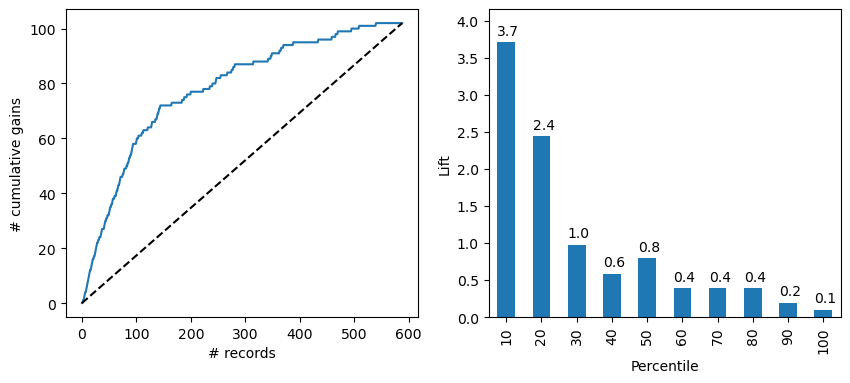

In [21]:
df = logit_result.sort_values(by=['p(1)'], ascending=False)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

gainsChart(df.actual, ax=axes[0])
liftChart(df.actual, title=False, ax=axes[1])

plt.show()

In [22]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, roc_curve, auc, roc_auc_score

In [23]:
precision = precision_score(valid_y, logit_reg_pred)
recall = recall_score(valid_y, logit_reg_pred)

In [24]:
tn, fp, fn, tp = confusion_matrix(valid_y, logit_reg_pred).ravel()
specificity = tn / (tn +fp)

In [25]:
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'Specificity: {specificity}')

Precision: 0.7105263157894737
Recall: 0.2647058823529412
Specificity: 0.977366255144033


In [26]:
    # Select only numerical columns for correlation
numerical_df = ibm_df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()

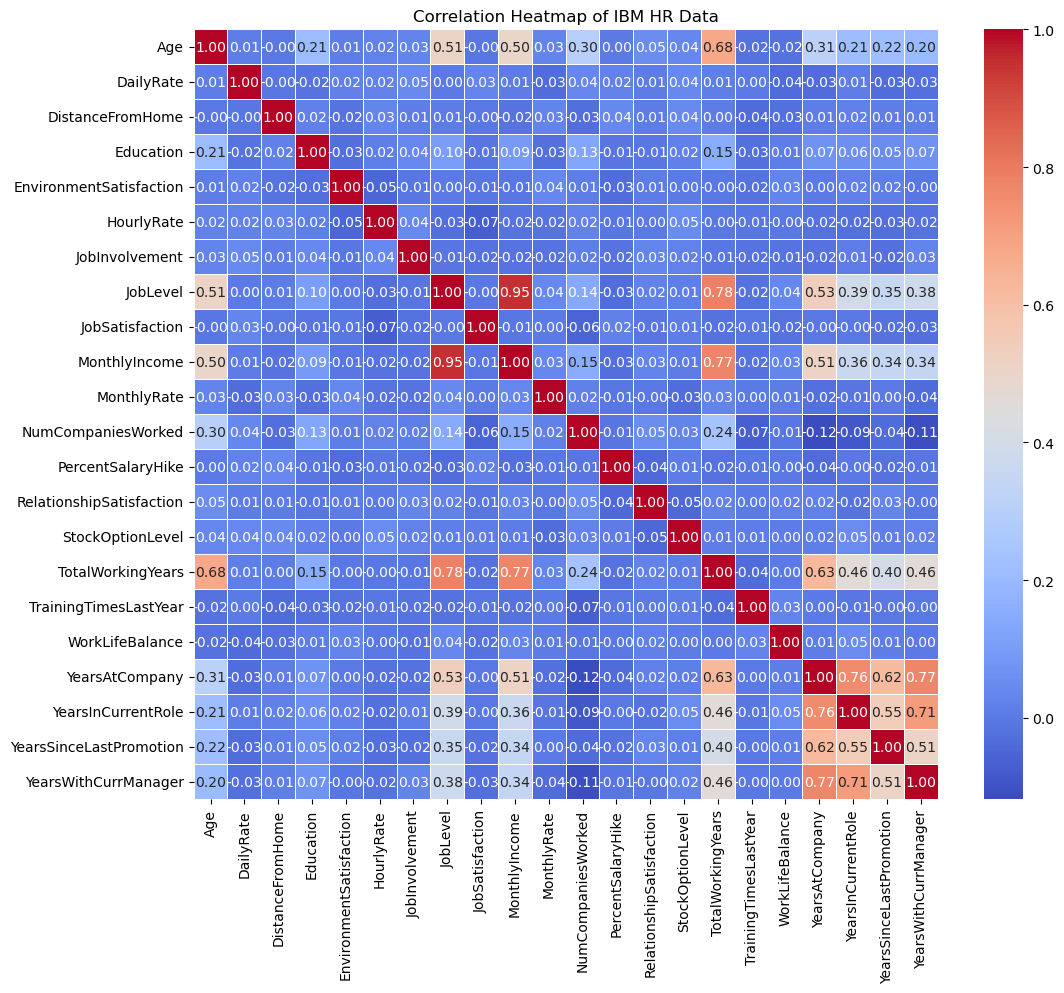

In [27]:
plt.figure(figsize=(12, 10)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of IBM HR Data')
plt.show()

In [28]:
# Classification Model
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Dataset (assuming the file is in your working directory)
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# 2. Drop Columns that wont get used
# Drop columns with only one unique value (like 'EmployeeCount', 'StandardHours', 'Over18') 
# or columns that are unique identifiers (like 'EmployeeNumber') as they don't help in clustering.
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_clust = df.drop(columns=cols_to_drop)

# 3. Separate Numerical and Categorical Features
numerical_features = df_clust.select_dtypes(include=np.number).columns.tolist()
categorical_features = df_clust.select_dtypes(include='object').columns.tolist()

# 4. Preprocessing Pipeline
# We need to scale numerical data and convert categorical data to numerical.
preprocessor = ColumnTransformer(
    transformers=[
        # Scale Numerical features (important for distance-based algorithms like K-Means)
        ('num', StandardScaler(), numerical_features),
        # One-Hot Encode Categorical features (to convert text to numbers)
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# 5. Transform the Data
df_2 = preprocessor.fit_transform(df_clust)

In [29]:
# 1. Choose the optimal K 
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# 2. Fit K-Means to the processed data and get cluster labels
cluster_labels = kmeans.fit_predict(df_2)

# 3. Add the cluster labels back to the original DataFrame
df['Cluster'] = cluster_labels

print(df['Cluster'].value_counts())

C:\Users\eddie\Anaconda3.1\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\eddie\Anaconda3.1\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\eddie\Anaconda3.1\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\eddie\Anaconda3.1\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^

Cluster
2    714
1    340
3    219
0    197
Name: count, dtype: int64


In [30]:
# Normalize distances
df_x = preprocessing.scale(df_2, axis=0)

In [31]:
kmeans = KMeans(n_clusters=11, random_state=42).fit(df_2)

C:\Users\eddie\Anaconda3.1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [32]:
# CLustering Membership
memb = pd.Series(kmeans.labels_, index=df.index)
for key, item in memb.groupby(memb):
    print(key, ':', ','.join(str(i) for i in item.index))

0 : 3,5,12,13,35,49,80,81,84,108,113,128,146,155,164,170,172,179,207,227,229,238,252,254,261,302,320,331,345,350,373,397,404,414,435,443,449,450,478,479,481,495,496,505,511,513,522,549,550,564,576,577,614,620,632,640,644,652,655,658,663,666,679,719,722,724,726,733,754,794,796,820,822,825,827,842,852,859,881,891,895,924,939,973,989,990,993,998,1017,1025,1046,1098,1101,1122,1125,1127,1134,1168,1201,1217,1233,1272,1317,1323,1358,1359,1364,1369,1376,1413,1417,1459
1 : 15,22,27,43,61,76,83,88,89,92,93,94,103,116,121,124,129,133,137,139,150,151,153,154,158,166,167,173,188,210,212,220,222,223,226,228,247,256,269,271,282,285,293,297,303,304,306,313,317,319,324,334,339,341,342,343,344,353,355,359,366,374,384,386,394,398,403,420,423,426,432,442,444,446,447,452,459,462,468,491,503,506,508,514,519,523,524,526,527,529,530,531,532,558,562,569,578,590,593,600,604,607,608,610,621,641,647,664,675,681,685,686,690,692,693,695,696,702,704,705,707,710,718,729,730,745,751,752,753,757,773,780,783,784,788,805

In [33]:
# CLuster centroids with K means
centroids = pd.DataFrame(kmeans.cluster_centers_)
pd.set_option('display.precision',3)
centroids

,0,1,2,3,4,5,6,7,8,9,...,43,44,45,46,47,48,49,50,51,52
0,-0.674,0.695,-0.168,-1.241,0.140,-0.192,0.104,-0.590,0.368,-0.502,...,0.080,2.082e-17,0.312,0.170,7.143e-02,0.196,0.491,3.125e-01,0.580,0.420
1,-0.049,-0.127,-0.083,0.187,0.113,-0.097,0.021,0.124,0.049,0.005,...,0.121,5.021e-02,0.142,0.381,1.674e-02,0.234,0.477,2.887e-01,0.753,0.247
2,-1.056,-0.727,-0.109,-0.403,0.198,0.121,-0.258,-0.802,-0.417,-0.757,...,0.023,6.939e-18,0.262,0.115,2.769e-01,0.038,0.269,6.923e-01,0.738,0.262
3,0.482,0.224,-0.471,0.452,0.296,-0.276,0.179,-0.241,-0.108,-0.292,...,0.143,7.519e-03,0.150,0.248,3.008e-02,0.158,0.444,3.985e-01,0.737,0.263
4,1.018,-0.093,-0.057,0.070,-0.120,-0.020,-0.174,1.757,-0.104,1.823,...,0.071,1.969e-01,0.008,0.157,-6.939e-18,0.252,0.496,2.520e-01,0.724,0.276
5,0.146,-0.125,0.853,0.054,-0.709,-0.007,0.155,-0.183,0.439,-0.268,...,0.096,2.128e-02,0.149,0.330,5.319e-02,0.213,0.415,3.723e-01,0.862,0.138
6,-0.540,0.126,-0.275,0.157,0.007,0.044,0.045,-0.599,0.098,-0.567,...,0.090,6.939e-18,0.279,0.180,8.197e-02,0.484,0.516,-5.551e-17,0.754,0.246
7,1.419,0.162,-0.151,0.243,0.089,0.049,0.099,1.801,0.125,1.915,...,0.133,3.333e-01,0.010,0.067,-6.939e-18,0.200,0.524,2.762e-01,0.705,0.295
8,-0.217,0.004,0.083,-0.108,-0.078,-0.024,0.004,-0.362,0.004,-0.375,...,0.123,1.604e-02,0.257,0.193,5.882e-02,0.214,0.465,3.209e-01,0.690,0.310
9,0.248,0.121,1.074,0.169,0.307,0.446,0.072,0.037,-0.471,-0.008,...,0.143,1.905e-02,0.181,0.381,1.388e-17,0.324,0.562,1.143e-01,0.638,0.362


In [34]:
# Within cluster sum of distances and cluster counts
distances = kmeans.transform(df_x)

minSquaredDistances = distances.min(axis=1) ** 2

data_ibm = pd.DataFrame({'squaredDistance': minSquaredDistances, 'cluster': kmeans.labels_},
                       index=df.index)
for cluster, data in data_ibm.groupby('cluster'):
    count = len(data)
    withinClustSS = data.squaredDistance.sum()
    print(f'Cluster {cluster} ({count} members): {withinClustSS: 2f} within cluster ')

Cluster 0 (112 members):  4726.073414 within cluster 
Cluster 1 (239 members):  11206.570673 within cluster 
Cluster 2 (130 members):  6506.091984 within cluster 
Cluster 3 (133 members):  6370.840992 within cluster 
Cluster 4 (127 members):  7399.646136 within cluster 
Cluster 5 (94 members):  4153.161580 within cluster 
Cluster 6 (122 members):  5733.601357 within cluster 
Cluster 7 (105 members):  5552.801604 within cluster 
Cluster 8 (187 members):  9355.186588 within cluster 
Cluster 9 (105 members):  4732.414131 within cluster 
Cluster 10 (116 members):  5273.425219 within cluster 


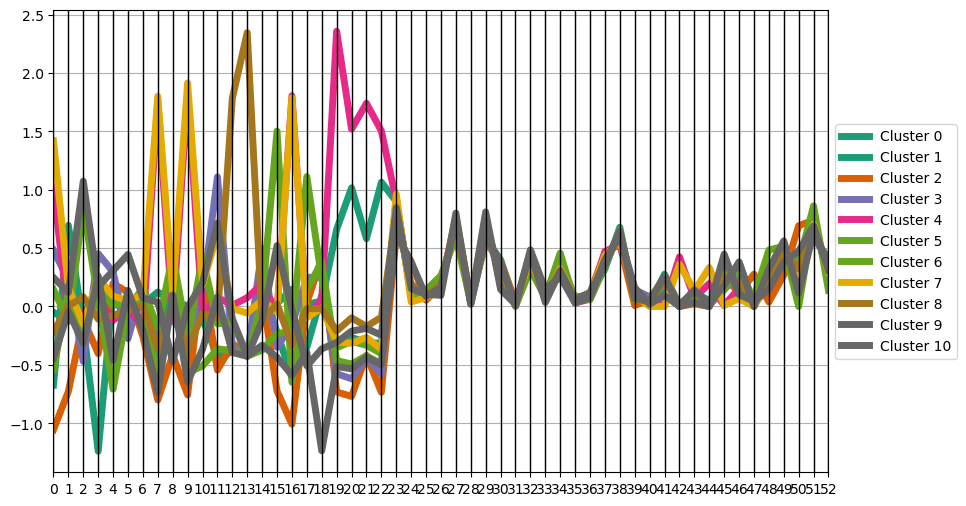

In [35]:
# Make a plot of the centroids
centroids['cluster'] = ['Cluster {}'.format(i) for i in centroids.index]

plt.figure(figsize=(10,6))
parallel_coordinates(centroids, class_column='cluster', colormap='Dark2', linewidth=5)
plt.legend(loc='center left', bbox_to_anchor=(1,0.5))